In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [3]:
train_path = "dataset/train"
test_path = "dataset/test"


In [4]:
img_size = (150,150)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

print("Classes:", train_data.class_indices)


Found 10901 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.
Classes: {'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


In [5]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

# Convolution Layer 2
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convolution Layer 3
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

# Output Layer (6 classes)
model.add(Dense(6, activation='softmax'))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       591,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 615,686 (2.35 MB)

 Trainable params: 615,686 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [7]:
history = model.fit(
    train_data,
    epochs=3,
    validation_data=test_data
)


Epoch 1/3
341/341 ━━━━━━━━━━━━━━━━━━━━ 2125s 6s/step - accuracy: 0.4889 - loss: 1.2702 - val_accuracy: 0.7628 - val_loss: 0.7876
Epoch 2/3
341/341 ━━━━━━━━━━━━━━━━━━━━ 186s 545ms/step - accuracy: 0.6574 - loss: 0.8714 - val_accuracy: 0.8321 - val_loss: 0.5130
Epoch 3/3
341/341 ━━━━━━━━━━━━━━━━━━━━ 176s 517ms/step - accuracy: 0.6986 - loss: 0.7550 - val_accuracy: 0.8766 - val_loss: 0.3746


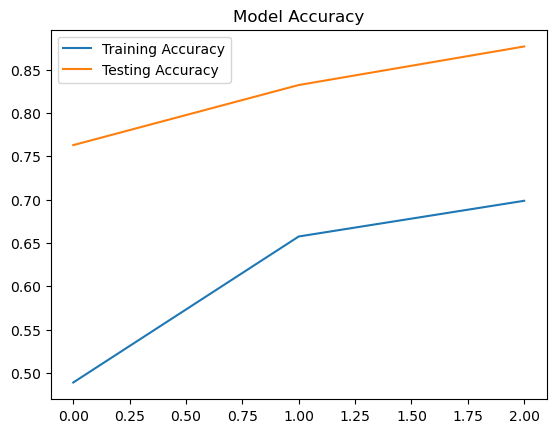

In [8]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [9]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy*100)


85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 230ms/step - accuracy: 0.8766 - loss: 0.3746
Test Accuracy: 87.6575231552124


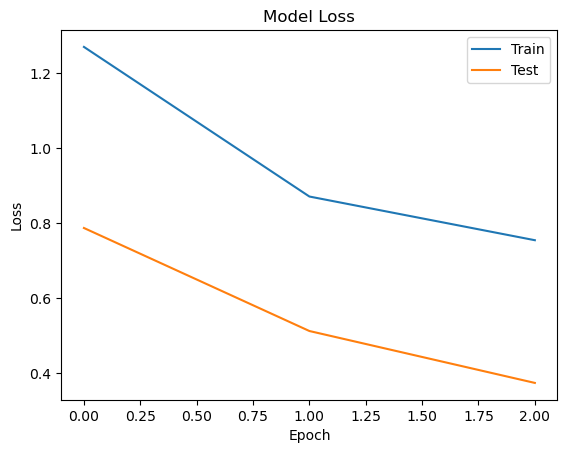

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()


In [11]:
img_path = "dataset/test/freshapples/Screen Shot 2018-06-08 at 4.59.44 PM.png"


In [16]:
prediction = model.predict(img_array)
class_index = np.argmax(prediction)


NameError: name 'img_array' is not defined

In [ ]:
class_labels = ['freshapples', 'freshbanana', 'freshoranges',
                'rottenapples', 'rottenbanana', 'rottenoranges']

print("Predicted Class:", class_labels[class_index])


Predicted Class: freshapples


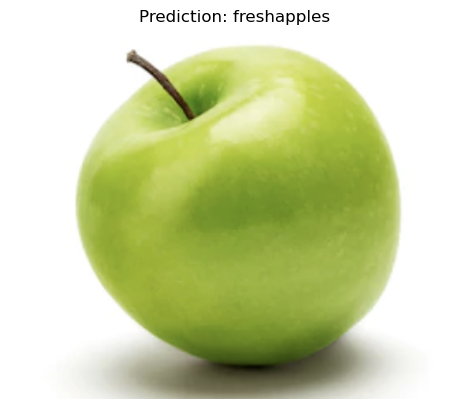

In [ ]:
plt.imshow(image.load_img(img_path))
plt.title("Prediction: " + class_labels[class_index])
plt.axis('off')
plt.show()


In [ ]:
model.save("fruit_freshness_model.h5")

In [ ]:
import os
print(os.getcwd())


c:\Users\hp\OneDrive\Desktop\projects\Fruit Freshness Classification


In [ ]:
import pickle

class_labels = list(train_data.class_indices.keys())

with open("class_labels.pkl", "wb") as f:
    pickle.dump(class_labels, f)


In [ ]:
with open("class_labels.pkl", "rb") as f:
    class_labels = pickle.load(f)

print(class_labels)


['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [ ]:
params = {
    "image_size": (150,150),
    "rescale": 1./255
}

with open("preprocessing_params.pkl", "wb") as f:
    pickle.dump(params, f)


In [ ]:
with open("fruit_model.pkl", "wb") as f:
    pickle.dump(model, f)
